<a href="https://colab.research.google.com/github/swayambel/numerical_integrator_analysis/blob/main/numerical_integrator_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numerical Integrator Stability Analysis

## 1. Introduction

Numerical integration methods are fundamental tools for solving dynamical systems that cannot be solved analytically. In celestial mechanics and orbital dynamics, the equations governing motion are often expressed as differential equations, which require numerical techniques to compute trajectories over time.

One of the simplest physical systems used to study numerical methods is the **two-body gravitational problem**, where a small body moves under the gravitational influence of a central mass. In an ideal analytical solution, certain physical quantities such as **total mechanical energy** and **angular momentum** remain conserved.

However, numerical integration methods introduce **truncation errors** at each timestep. Over long simulations these errors accumulate and can significantly alter the system’s behavior. As a result, different integrators exhibit different levels of stability and conservation accuracy.

The objective of this study is to investigate how various numerical integrators affect the long-term stability of orbital simulations.

Specifically, this project compares the following integration methods:

- Euler Method  
- Second-order Runge–Kutta (RK2)  
- Fourth-order Runge–Kutta (RK4)

The analysis focuses on three key diagnostics:

1. **Orbit geometry** – how the trajectory evolves over time  
2. **Energy conservation** – deviation of specific mechanical energy from its initial value  
3. **Radius drift** – long-term change in orbital radius  

By comparing these properties, we can understand how the order and structure of numerical integrators influence the accuracy and stability of gravitational simulations.

## 2. Two-Body Gravitational Model


In [3]:
import numpy as np
import matplotlib.pyplot as plt

GM = 1.0

def derivatives(state):
    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)

    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return np.array([vx, vy, ax, ay])


## 3. Euler Integrator

In [4]:
def euler_step(state, dt):
    return state + dt * derivatives(state)

In [5]:
dt = 0.01
steps = 5000

state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory = []

for _ in range(steps):
    trajectory.append(state[:2])
    state = euler_step(state, dt)

trajectory = np.array(trajectory)

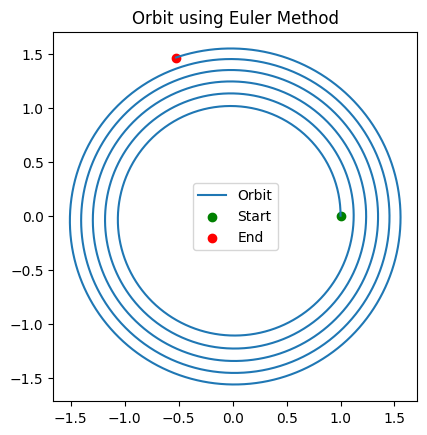

In [6]:
plt.plot(trajectory[:,0], trajectory[:,1], label="Orbit")
plt.scatter(trajectory[0,0], trajectory[0,1], color='green', label="Start")
plt.scatter(trajectory[-1,0], trajectory[-1,1], color='red', label="End")
plt.legend()
plt.gca().set_aspect('equal')
plt.title("Orbit using Euler Method")
plt.show()

## 4. RK2 Integrator



In [7]:
def rk2_step(state, dt):
    k1 = derivatives(state)
    k2 = derivatives(state + dt * k1)

    return state + 0.5 * dt * (k1 + k2)

In [8]:
dt = 0.01
steps = 5000

state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_rk2 = []

for _ in range(steps):
    trajectory_rk2.append(state[:2])
    state = rk2_step(state, dt)

trajectory_rk2 = np.array(trajectory_rk2)

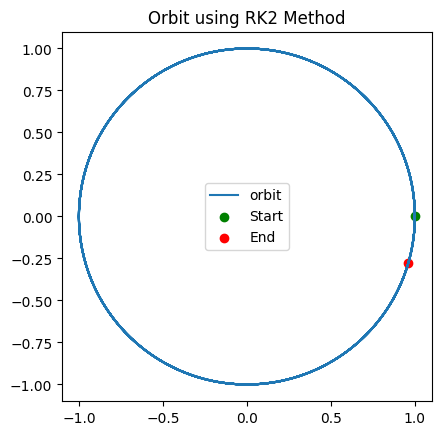

In [18]:
plt.plot(trajectory_rk2[:,0], trajectory_rk2[:,1], label ='orbit')
plt.scatter(trajectory_rk2[0,0], trajectory_rk2[0,1], color='green', label="Start")
plt.scatter(trajectory_rk2[-1,0], trajectory_rk2[-1,1], color='red', label="End")
plt.legend()
plt.gca().set_aspect('equal')
plt.title("Orbit using RK2 Method")
plt.show()

## 5. RK4 Integrator


In [11]:
def rk4_step(state, dt):
    k1 = derivatives(state)
    k2 = derivatives(state + 0.5 * dt * k1)
    k3 = derivatives(state + 0.5 * dt * k2)
    k4 = derivatives(state + dt * k3)

    return state + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

In [12]:
dt = 0.01
steps = 5000

state = np.array([1.0, 0.0, 0.0, 1.0])

trajectory_rk4 = []

for _ in range(steps):
    trajectory_rk4.append(state[:2])
    state = rk4_step(state, dt)

trajectory_rk4 = np.array(trajectory_rk4)

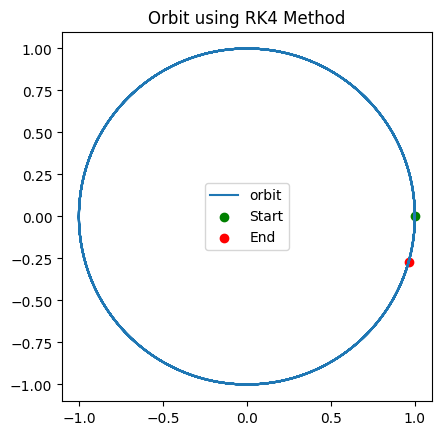

In [17]:
plt.plot(trajectory_rk4[:,0], trajectory_rk4[:,1], label='orbit')
plt.scatter(trajectory_rk4[0,0], trajectory_rk4[0,1], color='green', label="Start")
plt.scatter(trajectory_rk4[-1,0], trajectory_rk4[-1,1], color='red', label="End")
plt.legend()
plt.gca().set_aspect('equal')
plt.title("Orbit using RK4 Method")
plt.show()


## 6. Orbit Comparison



## 7. Energy Drift Analysis



## 8. Radius Drift Analysis


## 9. Conclusions